In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import csv
import os
from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path

Loading datasets

In [ ]:
#Inputs = pd.read_csv(r"C:\Neural\Project\Hysys sim_Datagenration\Inputs4.csv")
#Outputs = pd.read_csv(r"C:\Neural\Project\Hysys sim_Datagenration\Outputs4.csv")
DATA_DIR = Path("../data")
Inputs = pd.read_csv(DATA_DIR / "Inputs4.csv")
Outputs = pd.read_csv(DATA_DIR / "Outputs4.csv")

Checking for duplicated Inputs

In [3]:
duplicates = Inputs[Inputs.duplicated(keep = False)]
print(duplicates)
print("Number of duplicated rows: ", Inputs.duplicated().sum())

Empty DataFrame
Columns: [IBPL, 10%L, 20%L, 30%L, 40%L, 50%L, 60%L, 70%L, 80%L, 90%L, FBP, MW, Density]
Index: []
Number of duplicated rows:  0


MinMax Normalization for each column

In [4]:
col_min = Inputs.min()
col_max = Inputs.max()


In [5]:
Inputs_normalized = Inputs.apply(lambda x: (x - x.min())/(x.max()-x.min()))
Outputs_normalized = Outputs.apply(lambda x: (x - x.min())/(x.max()-x.min()))
Inputs_normalized

,IBPL,10%L,20%L,30%L,40%L,50%L,60%L,70%L,80%L,90%L,FBP,MW,Density
0,0.201800,0.235934,0.273094,0.320429,0.376343,0.442708,0.523377,0.618291,0.690094,0.739501,0.770600,0.282928,0.585876
1,0.218715,0.231941,0.240362,0.251240,0.264776,0.280858,0.296505,0.301787,0.265076,0.197915,0.205423,0.298693,0.290900
2,0.419173,0.479529,0.540984,0.613051,0.683396,0.750755,0.818582,0.887452,0.918724,0.926897,0.910625,0.496420,0.875924
3,0.141645,0.154545,0.168168,0.187589,0.213177,0.243857,0.279325,0.318824,0.342155,0.366940,0.474432,0.308694,0.200038
4,0.380314,0.416411,0.443884,0.475800,0.510770,0.556543,0.619623,0.699908,0.761621,0.817507,0.880587,0.580761,0.534192
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93549,0.163613,0.167122,0.170518,0.178964,0.193065,0.209849,0.223249,0.222660,0.177639,0.091804,0.066013,0.283113,0.148917
93550,0.466836,0.487006,0.494806,0.503770,0.509547,0.516244,0.524752,0.526425,0.484946,0.417670,0.404553,0.539885,0.443260
93551,0.440252,0.455155,0.474574,0.515081,0.572806,0.648776,0.740464,0.837158,0.887640,0.898487,0.886521,0.477001,0.701151
93552,0.435327,0.412378,0.387430,0.376804,0.382453,0.410539,0.464592,0.544301,0.620189,0.701784,0.793096,0.348882,0.482103


Standard Normalization for each column

In [6]:
Inputs_standardized = Inputs.apply(lambda x: (x - x.mean())/(x.std()))
Outputs_standardized = Outputs.apply(lambda x: (x - x.mean())/(x.std()))
Inputs_standardized

,IBPL,10%L,20%L,30%L,40%L,50%L,60%L,70%L,80%L,90%L,FBP,MW,Density
0,-1.030030,-0.912496,-0.768543,-0.614842,-0.464436,-0.313787,-0.144959,0.058628,0.282661,0.459796,0.466793,-1.018241,0.326984
1,-0.923675,-0.937277,-0.969253,-1.025491,-1.109034,-1.223083,-1.368584,-1.551380,-1.771699,-2.016094,-2.247861,-0.911916,-1.167811
2,0.336701,0.599242,0.874136,1.121918,1.309609,1.416857,1.447221,1.427808,1.387763,1.316484,1.139362,0.421596,1.796812
3,-1.408248,-1.417594,-1.411939,-1.403271,-1.407154,-1.430959,-1.461249,-1.464712,-1.399132,-1.243388,-0.955761,-0.844468,-1.628261
4,0.092376,0.207535,0.278727,0.307312,0.312237,0.325751,0.374138,0.473803,0.628390,0.816403,0.995081,0.990407,0.065076
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93549,-1.270126,-1.339543,-1.397534,-1.454460,-1.523354,-1.622023,-1.763691,-1.953884,-2.194332,-2.501183,-2.917478,-1.016994,-1.887318
93550,0.636383,0.645648,0.590973,0.473314,0.305169,0.099347,-0.137542,-0.408678,-0.708942,-1.011473,-1.291405,0.714731,-0.395725
93551,0.469233,0.447979,0.466914,0.540452,0.670661,0.843925,1.025894,1.171972,1.237514,1.186606,1.023584,0.290626,0.911144
93552,0.438272,0.182505,-0.067444,-0.280250,-0.429136,-0.494518,-0.462016,-0.317747,-0.055231,0.287368,0.574844,-0.573430,-0.198888


Extracting Input Output values

In [7]:
x = Inputs_normalized.values.astype("float32")
y = Outputs.values.astype("float32")

Shuffling Inputs and Outputs

In [8]:
x, y = shuffle(x, y, random_state=42)

Generating Datas for train, validation and test

In [9]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5)

Neural Network for Normalized Outputs

In [260]:
inp1 = keras.layers.Input(shape=x_train.shape[1:])

x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(inp1)
x1 = keras.layers.Activation('relu')(x1)
out1 = keras.layers.Dense(5, activation='linear', name='PIONA')(x1)


p = keras.layers.Lambda(lambda t: t[:, 0:1])(out1)
i = keras.layers.Lambda(lambda t: t[:, 1:2])(out1)
o = keras.layers.Lambda(lambda t: t[:, 2:3])(out1)
n = keras.layers.Lambda(lambda t: t[:, 3:4])(out1)
a = keras.layers.Lambda(lambda t: t[:,4:5])(out1)



inp = keras.layers.concatenate([p, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(inp)
x1p = keras.layers.Activation('relu')(x1)

ini = keras.layers.concatenate([i, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(ini)
x2i = keras.layers.Activation('relu')(x1)

ino = keras.layers.concatenate([o, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(ino)
x3o = keras.layers.Activation('relu')(x1)

inn = keras.layers.concatenate([n, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(inn)
x4n = keras.layers.Activation('relu')(x1)

ina = keras.layers.concatenate([a, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(ina)
x5a = keras.layers.Activation('relu')(x1)


conc1 = keras.layers.concatenate([x1p, x2i, x3o, x4n, x5a])
out2 = keras.layers.Dense(20, activation='linear', name='Compositions')(conc1)
out = keras.layers.concatenate([out2,p,i,o,n,a])
model = keras.Model(inputs = inp1, outputs =out)

Neural Network for non-normalized Outputs

First Structure

In [25]:
inp1 = keras.layers.Input(shape=x_train.shape[1:])

x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(inp1)
x1 = keras.layers.Activation('relu')(x1)
out1 = keras.layers.Dense(5, activation='sigmoid')(x1)

p = keras.layers.Lambda(lambda t: t[:, 0:1])(out1)
i = keras.layers.Lambda(lambda t: t[:, 1:2])(out1)
o = keras.layers.Lambda(lambda t: t[:, 2:3])(out1)
n = keras.layers.Lambda(lambda t: t[:, 3:4])(out1)
a = keras.layers.Lambda(lambda t: t[:,4:5])(out1)

inp = keras.layers.concatenate([p, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(inp)
x1p = keras.layers.Activation('relu')(x1)
x1p2 = keras.layers.Dense(4, activation='sigmoid')(x1p)

ini = keras.layers.concatenate([i, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(ini)
x2i = keras.layers.Activation('relu')(x1)
x2i2 = keras.layers.Dense(5, activation='sigmoid')(x2i)

ino = keras.layers.concatenate([o, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(ino)
x3o = keras.layers.Activation('relu')(x1)
x3o2 = keras.layers.Dense(3, activation='sigmoid')(x3o)

inn = keras.layers.concatenate([n, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(inn)
x4n = keras.layers.Activation('relu')(x1)
x4n2 = keras.layers.Dense(4, activation='sigmoid')(x4n)

ina = keras.layers.concatenate([a, inp1])
x1 = keras.layers.Dense(20, kernel_initializer = 'he_normal')(ina)
x5a = keras.layers.Activation('relu')(x1)
x5a2 = keras.layers.Dense(4, activation='sigmoid')(x5a)

out = keras.layers.concatenate([x1p2,x2i2,x3o2,x4n2,x5a2,p,i,o,n,a])
model = keras.Model(inputs = inp1, outputs =out)

In [26]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 20)        │        280 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 20)        │          0 │ dense_16[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 5)         │        105 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 1)         │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 1)         │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 1)         │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 1)         │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_14 (Lambda)  │ (None, 1)         │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 14)        │          0 │ lambda_10[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 14)        │          0 │ lambda_11[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 14)        │          0 │ lambda_12[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 14)        │          0 │ lambda_13[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 14)        │          0 │ lambda_14[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 20)        │        300 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 20)        │        300 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 20)        │        300 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 20)        │        300 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 20)        │        300 │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 20)        │          0 │ dense_18[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 20)        │          0 │ dense_20[0][0]  

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

Learning Schedule

In [44]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=500,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-6
)



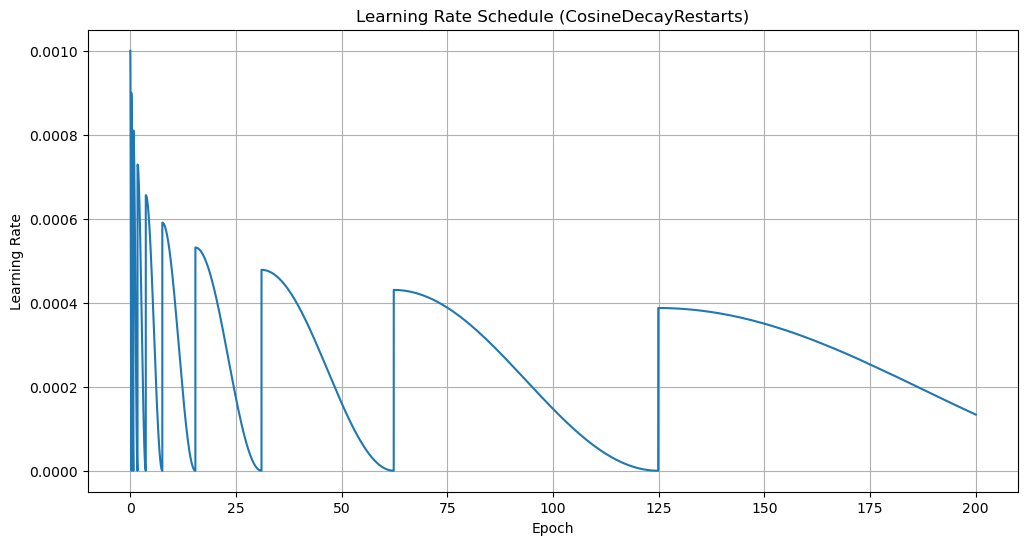

2046

In [45]:
epochs = 200
batch_size = 32
steps_per_epoch = len(x_train) // batch_size
total_steps = epochs * steps_per_epoch


steps = tf.range(total_steps, dtype=tf.float32)
lrs = lr_schedule(steps).numpy()

plt.figure(figsize=(12,6))
plt.plot(steps.numpy() / steps_per_epoch, lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule (CosineDecayRestarts)")
plt.grid(True)
plt.show()
steps_per_epoch

Callbacks

In [46]:
er_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

Defining optimizer, loss and metrics

In [30]:
model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate = lr_schedule),
        loss='huber',
        metrics=["mse", 'mae']
    )

Fitting the model

In [31]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=600, batch_size = 32, callbacks=[er_stop], shuffle=True)


Epoch 1/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0135 - mae: 0.0966 - mse: 0.0269 - val_loss: 3.4159e-04 - val_mae: 0.0203 - val_mse: 6.8318e-04
Epoch 2/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.3636e-04 - mae: 0.0163 - mse: 4.7273e-04 - val_loss: 1.0573e-04 - val_mae: 0.0107 - val_mse: 2.1146e-04
Epoch 3/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 7.9797e-05 - mae: 0.0092 - mse: 1.5959e-04 - val_loss: 4.8727e-05 - val_mae: 0.0074 - val_mse: 9.7454e-05
Epoch 4/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.7417e-05 - mae: 0.0073 - mse: 9.4833e-05 - val_loss: 4.2879e-05 - val_mae: 0.0069 - val_mse: 8.5758e-05
Epoch 5/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.0726e-05 - mae: 0.0066 - mse: 8.1453e-05 - val_loss: 3.6546e-05 - val_mae: 0.0062 - val_mse: 7.3091e-05
Epoch 6/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.5371e-05 - mae: 0.0061 - mse: 7.0742e-05 - val_loss: 3.4551e-05 - val_mae: 0.0059 - val_mse: 6.910

Validation and Test plots

In [203]:
def ends(ax, x, y, fmt="{:.6f}", size=10):
    y = np.asarray(y); x = np.asarray(x)

    first_up = (len(y) > 1 and y[1] < y[0])   
    last_up  = (len(y) > 1 and y[-1] >= y[-2])


    ax.annotate(fmt.format(y[0]), (x[0], y[0]),
                textcoords="offset points",
                xytext=(6, 10 if first_up else -14),
                ha="left", va="bottom" if first_up else "top",
                fontweight="bold", fontsize=size,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))
    ax.annotate(fmt.format(y[-1]), (x[-1], y[-1]),
                textcoords="offset points",
                xytext=(-6, 10 if last_up else -14),
                ha="right", va="bottom" if last_up else "top",
                fontweight="bold", fontsize=size,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

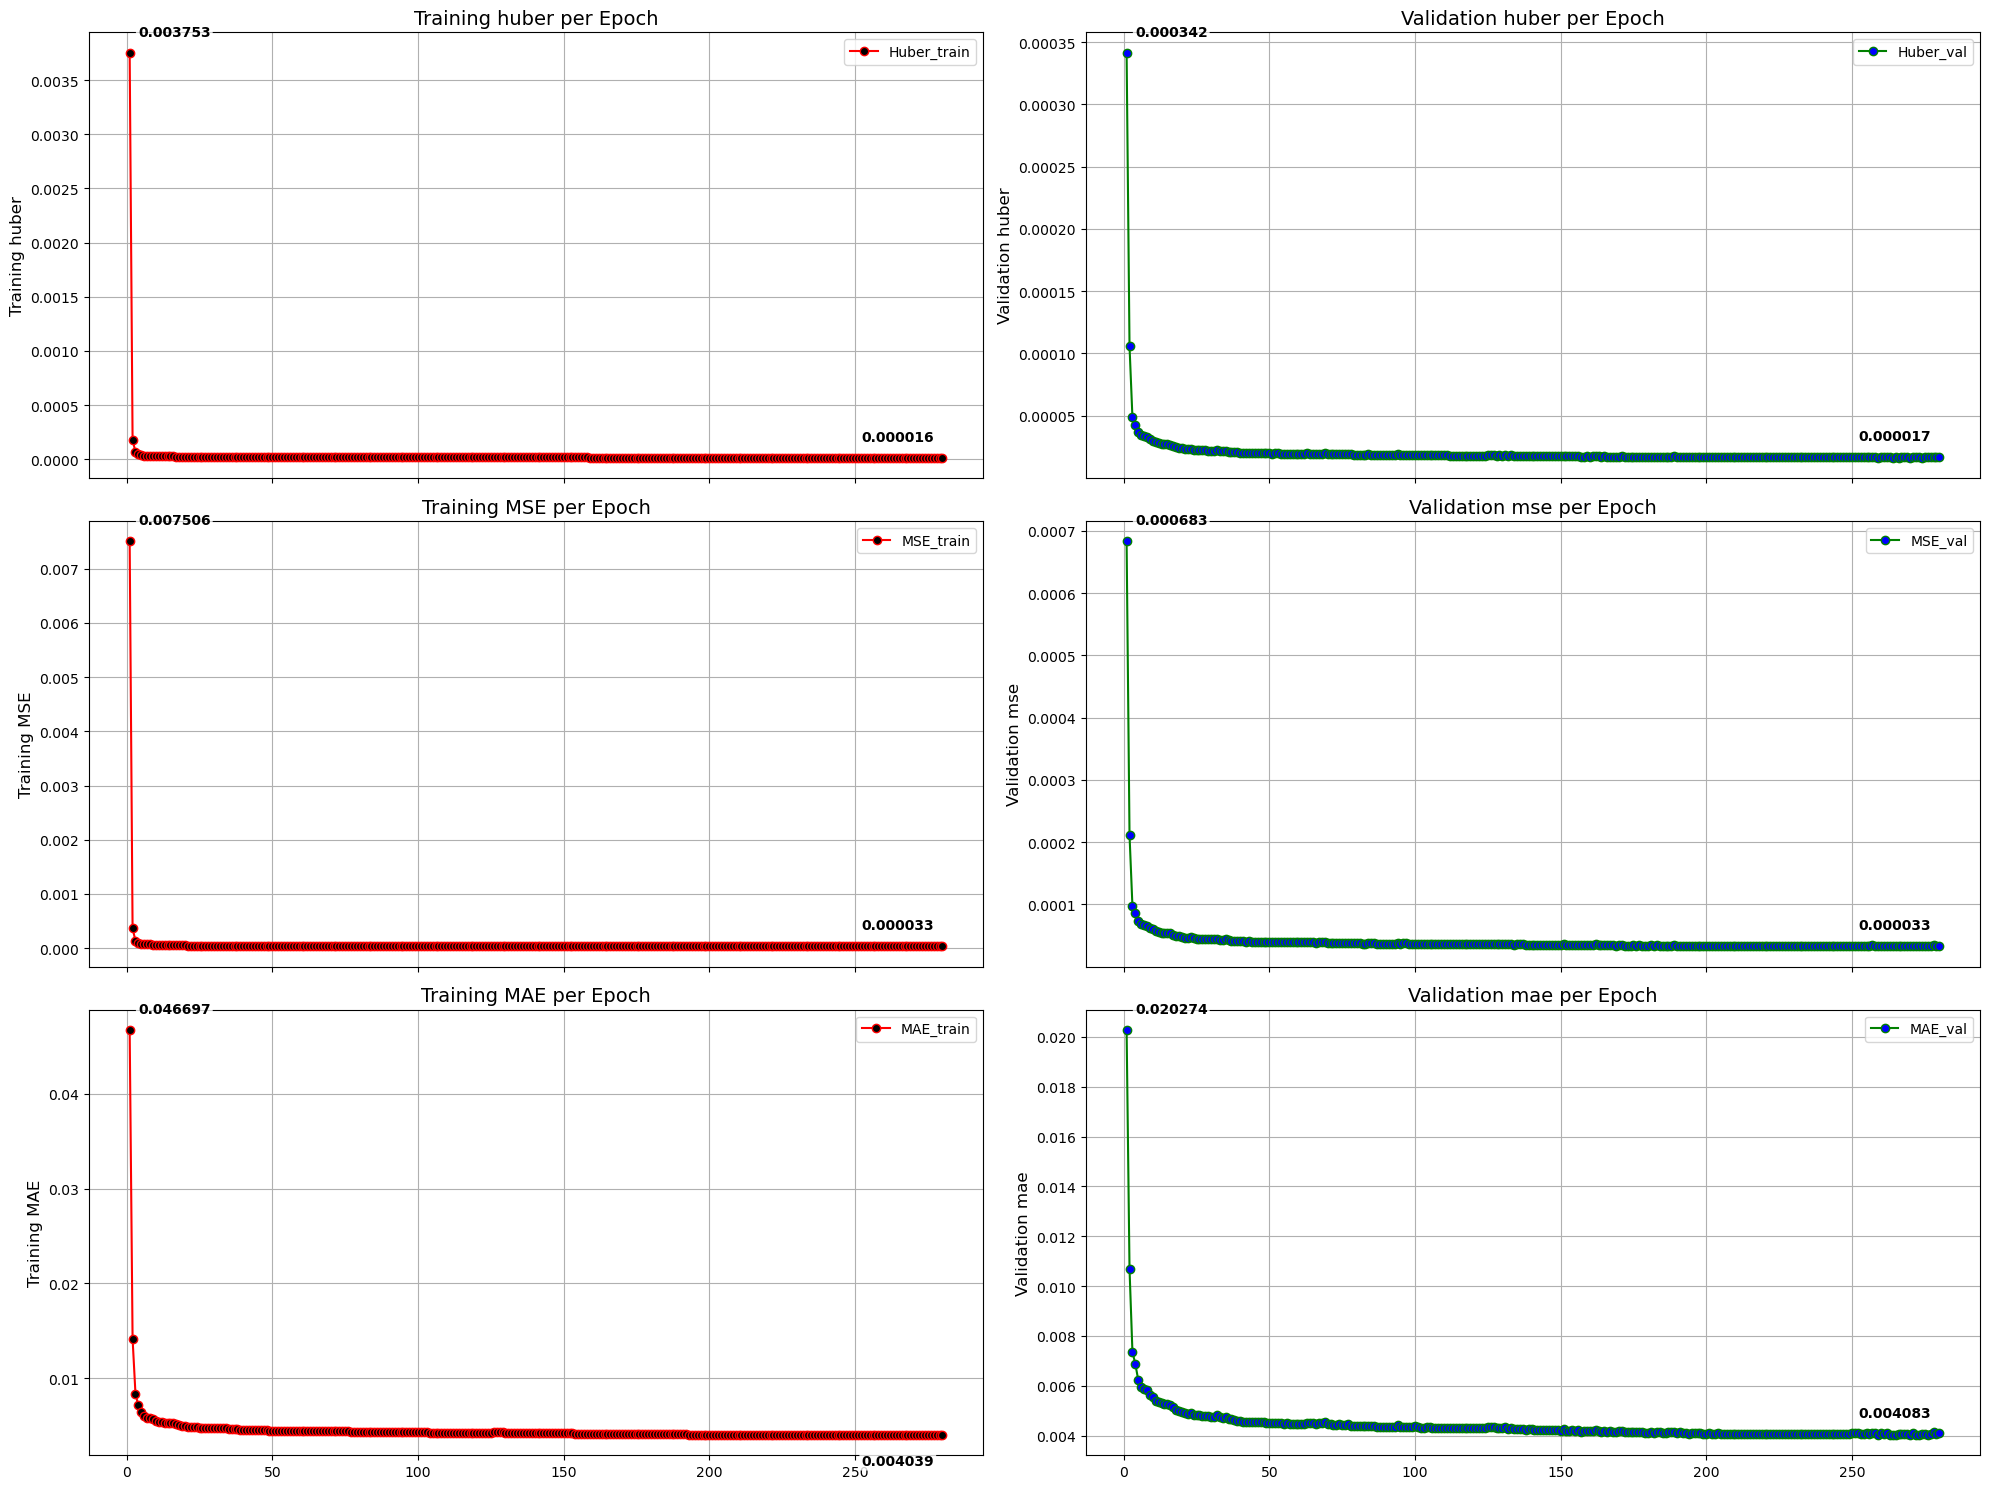

In [ ]:
train_huber = history.history['loss']
val_huber = history.history['val_loss']
train_mse = history.history['mse']
val_mse = history.history['val_mse']
train_mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(train_huber) + 1)

fig, axs = plt.subplots(3, 2, figsize=(20, 15), sharex=True)


axs[0,0].plot(epochs, train_huber, label='Huber_train', marker='o', markerfacecolor='black', color='red')
ends(axs[0,0], epochs, train_huber, fmt="{:.6f}")
axs[0,0].set_ylabel('Training huber', fontsize=12)
axs[0,0].set_title('Training huber per Epoch', fontsize=14)
axs[0,0].grid(True)
axs[0,0].legend()

axs[0,1].plot(epochs, val_huber, label='Huber_val', marker='o', markerfacecolor='blue', color='green')
ends(axs[0,1], epochs, val_huber, fmt="{:.6f}")
axs[0,1].set_ylabel('Validation huber', fontsize=12)
axs[0,1].set_title('Validation huber per Epoch', fontsize=14)
axs[0,1].grid(True)
axs[0,1].legend()

axs[1,0].plot(epochs, train_mse, label='MSE_train', marker='o', markerfacecolor='black', color='red')
ends(axs[1,0], epochs, train_mse, fmt="{:.6f}")
axs[1,0].set_ylabel('Training MSE', fontsize=12)
axs[1,0].set_title('Training MSE per Epoch', fontsize=14)
axs[1,0].grid(True)
axs[1,0].legend()

axs[1,1].plot(epochs, val_mse, label='MSE_val', marker='o', markerfacecolor='blue', color='green')
ends(axs[1,1], epochs, val_mse, fmt="{:.6f}")
axs[1,1].set_ylabel('Validation mse', fontsize=12)
axs[1,1].set_title('Validation mse per Epoch', fontsize=14)
axs[1,1].grid(True)
axs[1,1].legend()

axs[2,0].plot(epochs, train_mae, label='MAE_train', marker='o', markerfacecolor='black', color='red')
ends(axs[2,0], epochs, train_mae, fmt="{:.6f}")
axs[2,0].set_ylabel('Training MAE', fontsize=12)
axs[2,0].set_title('Training MAE per Epoch', fontsize=14)
axs[2,0].grid(True)
axs[2,0].legend()

axs[2,1].plot(epochs, val_mae, label='MAE_val', marker='o', markerfacecolor='blue', color='green')
ends(axs[2,1], epochs, val_mae, fmt="{:.6f}")
axs[2,1].set_ylabel('Validation mae', fontsize=12)
axs[2,1].set_title('Validation mae per Epoch', fontsize=14)
axs[2,1].grid(True)
axs[2,1].legend()

plt.tight_layout()
plt.show()

Testing the constraints of ouputs on validation and test datas

In [32]:
idx_P = [0,1,2,3]
idx_I = [4,5,6,7,8]
idx_O = [9,10,11]
idx_N = [12,13,14,15]
idx_A = [16,17,18,19]

def evaluate_25(model, X, y_true_25, name="VAL"):
    y_pred_25 = model.predict(X, verbose=0)

    y20_t, y5_t = y_true_25[:, :20], y_true_25[:, 20:]
    y20_p, y5_p = y_pred_25[:, :20], y_pred_25[:, 20:]

    mae20  = np.mean(np.abs(y20_t - y20_p))
    rmse20 = np.sqrt(np.mean((y20_t - y20_p)**2))
    mae5   = np.mean(np.abs(y5_t  - y5_p))
    rmse5  = np.sqrt(np.mean((y5_t  - y5_p)**2))

    neg_rate_20 = np.mean((y20_p < 0).any(axis=1))
    neg_rate_5  = np.mean((y5_p  < 0).any(axis=1))

    sum20 = y20_p.sum(axis=1)
    sum5  = y5_p.sum(axis=1)
    sum20_mean = float(sum20.mean())
    sum20_mae  = float(np.mean(np.abs(sum20 - 1.0)))
    sum5_mean  = float(sum5.mean())
    sum5_mae   = float(np.mean(np.abs(sum5  - 1.0)))

    def parents_from_20(y20):
        P = y20[:, idx_P].sum(axis=1, keepdims=True)
        I = y20[:, idx_I].sum(axis=1, keepdims=True)
        O = y20[:, idx_O].sum(axis=1, keepdims=True)
        N = y20[:, idx_N].sum(axis=1, keepdims=True)
        A = y20[:, idx_A].sum(axis=1, keepdims=True)
        return np.hstack([P,I,O,N,A])

    y5_from20_p = parents_from_20(y20_p)

    grp_parent_mismatch_pred = np.mean(np.abs(y5_from20_p - y5_p))
    grp_parent_mismatch_true = np.mean(np.abs(y5_from20_p - y5_t))

    print(f"\n=== {name} ===")
    print(f"MAE (20 comps)                 : {mae20:.6f}")
    print(f"RMSE (20 comps)                : {rmse20:.6f}")
    print(f"MAE (PIONA 5)                  : {mae5:.6f}")
    print(f"RMSE (PIONA 5)                 : {rmse5:.6f}")
    print(f"Neg rate (20)                  : {neg_rate_20*100:.2f}%")
    print(f"Neg rate (5)                   : {neg_rate_5*100:.2f}%")
    print(f"Sum(20) mean / |err|           : {sum20_mean:.6f} / {sum20_mae:.6f}")
    print(f"Sum(5)  mean / |err|           : {sum5_mean:.6f} / {sum5_mae:.6f}")
    print(f"Group-sum vs parent (pred) MAE : {grp_parent_mismatch_pred:.6f}")
    print(f"Group-sum vs parent (true)  MAE: {grp_parent_mismatch_true:.6f}")

    return y20_p, y5_p

In [33]:
y_val_pred = evaluate_25(model, x_val, y_val, name="VAL")


=== VAL ===
MAE (20 comps)                 : 0.003443
RMSE (20 comps)                : 0.004802
MAE (PIONA 5)                  : 0.006460
RMSE (PIONA 5)                 : 0.008472
Neg rate (20)                  : 0.00%
Neg rate (5)                   : 0.00%
Sum(20) mean / |err|           : 0.998419 / 0.004431
Sum(5)  mean / |err|           : 0.999857 / 0.002146
Group-sum vs parent (pred) MAE : 0.002424
Group-sum vs parent (true)  MAE: 0.006216


In [34]:
y_test_pred = evaluate_25(model, x_test, y_test, name="test")


=== test ===
MAE (20 comps)                 : 0.003423
RMSE (20 comps)                : 0.004774
MAE (PIONA 5)                  : 0.006442
RMSE (PIONA 5)                 : 0.008417
Neg rate (20)                  : 0.00%
Neg rate (5)                   : 0.00%
Sum(20) mean / |err|           : 0.998484 / 0.004440
Sum(5)  mean / |err|           : 0.999855 / 0.002144
Group-sum vs parent (pred) MAE : 0.002431
Group-sum vs parent (true)  MAE: 0.006178


Test datas evaluation

In [10]:
model = keras.models.load_model('ReLU.keras', safe_mode=False)

In [11]:
model.evaluate(x_test, y_test, return_dict=True)

439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6137e-05 - mae: 0.0040 - mse: 3.2275e-05


{'loss': 1.6201471225940622e-05,
 'mae': 0.00402709050104022,
 'mse': 3.2402942451881245e-05}

In [12]:
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.4f}")


439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
RMSE: 0.0057


In [13]:
def smape_per_col(y_true, y_pred, eps=1e-8):
  
    num = np.abs(y_pred - y_true)
    den = np.abs(y_true) + np.abs(y_pred) + eps
    return 100.0 * np.mean(num / den, axis=0)

def mse_per_col(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2, axis=0)

def rmse_per_col(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

def mae_per_col(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=0)

def relative_error_per_col(y_true, y_pred, eps=1e-8):
    rel_error = np.mean(np.abs(y_pred - y_true) / (np.abs(y_true) + eps), axis=0)
    return 100 * rel_error

In [28]:
SMAPE = smape_per_col(y_test, y_pred)
MSE = mse_per_col(y_test, y_pred)
MAE = mae_per_col(y_test, y_pred)
RMSE = rmse_per_col(y_test, y_pred)
RE = relative_error_per_col(y_test, y_pred)
SMAPE

array([ 6.006028  ,  5.8807173 ,  5.4789863 ,  4.5700746 ,  3.4224443 ,
        2.5442388 ,  5.47735   ,  7.6253257 ,  1.0254545 ,  5.254797  ,
        4.052878  ,  7.7010365 ,  4.5757174 ,  4.5202026 ,  3.1891656 ,
        5.223781  , 15.578586  ,  1.3273885 ,  6.5240874 ,  1.4168142 ,
        2.8188355 ,  1.0489223 ,  3.8758192 ,  2.049216  ,  0.71003616],
      dtype=float32)

In [15]:
MSE

array([2.03960026e-05, 7.21971955e-05, 9.65618256e-06, 6.90932666e-06,
       8.27279291e-06, 4.64514633e-05, 4.48728315e-05, 4.44416110e-05,
       8.39222321e-06, 4.28648900e-06, 3.08741146e-05, 3.62493338e-05,
       1.35321579e-05, 1.30967255e-05, 1.54420941e-05, 3.94664639e-05,
       2.45242586e-06, 1.81835730e-05, 1.28927204e-05, 7.75774697e-06,
       9.46273649e-05, 7.79277907e-05, 9.77014861e-05, 6.63239989e-05,
       1.76686281e-05], dtype=float32)

In [16]:
MAE

array([0.00352212, 0.00651885, 0.00256719, 0.00213603, 0.00229488,
       0.00535618, 0.0052124 , 0.00522675, 0.00228406, 0.00169794,
       0.00396093, 0.00430845, 0.00287338, 0.00283917, 0.00299038,
       0.00485532, 0.00135193, 0.00342814, 0.00286738, 0.00217438,
       0.0078281 , 0.00708366, 0.00738458, 0.00655832, 0.00335674],
      dtype=float32)

In [17]:
RMSE

array([0.00451619, 0.00849689, 0.00310744, 0.00262856, 0.00287625,
       0.00681553, 0.00669872, 0.00666645, 0.00289693, 0.00207038,
       0.00555645, 0.00602074, 0.00367861, 0.00361894, 0.00392964,
       0.00628223, 0.00156602, 0.00426422, 0.00359064, 0.00278527,
       0.00972766, 0.00882767, 0.00988441, 0.00814395, 0.00420341],
      dtype=float32)

In [20]:
RE

array([13.236245 , 12.139254 , 10.957576 ,  9.0756645,  6.9335475,
        5.0717297, 11.3078785, 16.013609 ,  2.0431416, 10.876261 ,
        8.604387 , 18.315899 ,  9.457222 ,  9.115358 ,  6.3606596,
       10.783289 , 32.686104 ,  2.6742973, 13.924774 ,  2.8276098,
        5.6876197,  2.0999336,  7.9965854,  4.1256213,  1.4200993],
      dtype=float32)

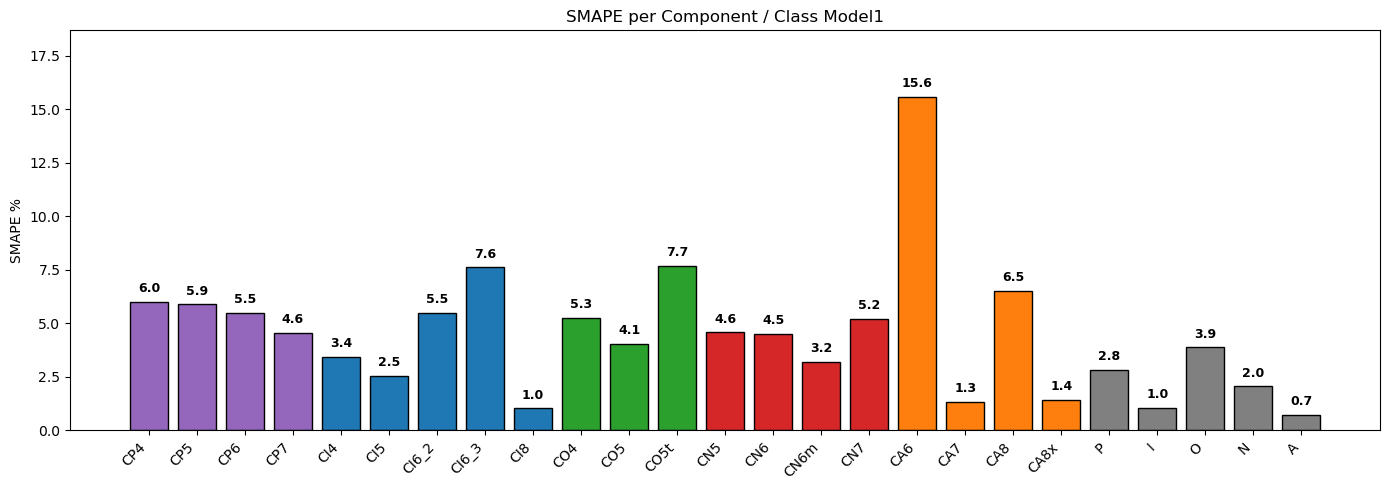

In [29]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O",'N',"A"]
colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, SMAPE, color=colors, edgecolor='black')


y_off = 0.02 * np.max(SMAPE)

for bar, val in zip(bars, SMAPE):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.1f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("SMAPE %")
ax.set_title("SMAPE per Component / Class Model1")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(SMAPE) * 1.2)

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib as mpl

mpl.rcParams["animation.ffmpeg_path"] = r"C:\Users\Rayanegostar\anaconda3\Library\bin\ffmpeg.exe"

# ------------------------------------------------------------------
# 1) Your data
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O",'N',"A"]


# Colors EXACTLY like your code
colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

# Optional: if ffmpeg isn't on PATH, set it explicitly:
# import matplotlib as mpl
# mpl.rcParams["animation.ffmpeg_path"] = r"C:\Users\...\ffmpeg.exe"
# ------------------------------------------------------------------

# 2) Figure & initial bars (height=0)
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, np.zeros_like(SMAPE), color=colors, edgecolor='black')

ax.set_ylabel("SMAPE %")
ax.set_title("SMAPE per Component / Class Model1")
plt.xticks(rotation=45, ha='right')

ymax = float(SMAPE.max()) * 1.2
ax.set_ylim(0, ymax)
y_off = 0.02 * SMAPE.max()  # label offset

# Create text labels once; we’ll update their positions/text in the animation
labels = []
for bar in bars:
    txt = ax.text(
        bar.get_x() + bar.get_width() / 2,
        0.0,
        "", ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
    labels.append(txt)

# 3) Animation
frames = 160          # more frames = smoother, fewer = faster
fps     = 40          # output video speed
# Use a smooth easing for a nice ramp (0..1 -> 0..1)
def ease(t):  # cubic ease-out
    return 1 - (1 - t) ** 3

def init():
    for bar in bars:
        bar.set_height(0.0)
    for txt in labels:
        txt.set_text("")
        txt.set_y(0.0)
    return (*bars, *labels)

def update(f):
    t = ease(f / (frames - 1))
    heights = SMAPE * t
    for bar, h, val, txt in zip(bars, heights, SMAPE, labels):
        bar.set_height(h)
        txt.set_text(f"{(val*t):.1f}")  # current animated value
        txt.set_y(h + y_off)
    return (*bars, *labels)

anim = FuncAnimation(
    fig, update, init_func=init, frames=frames,
    interval=1000/fps, blit=True
)

# 4) Save MP4
writer = FFMpegWriter(fps=fps, bitrate=3000)
anim.save("SMAPE_bars.mp4", writer=writer)
plt.close(fig)
print("Saved: SMAPE_bars.mp4")

Saved: SMAPE_bars.mp4


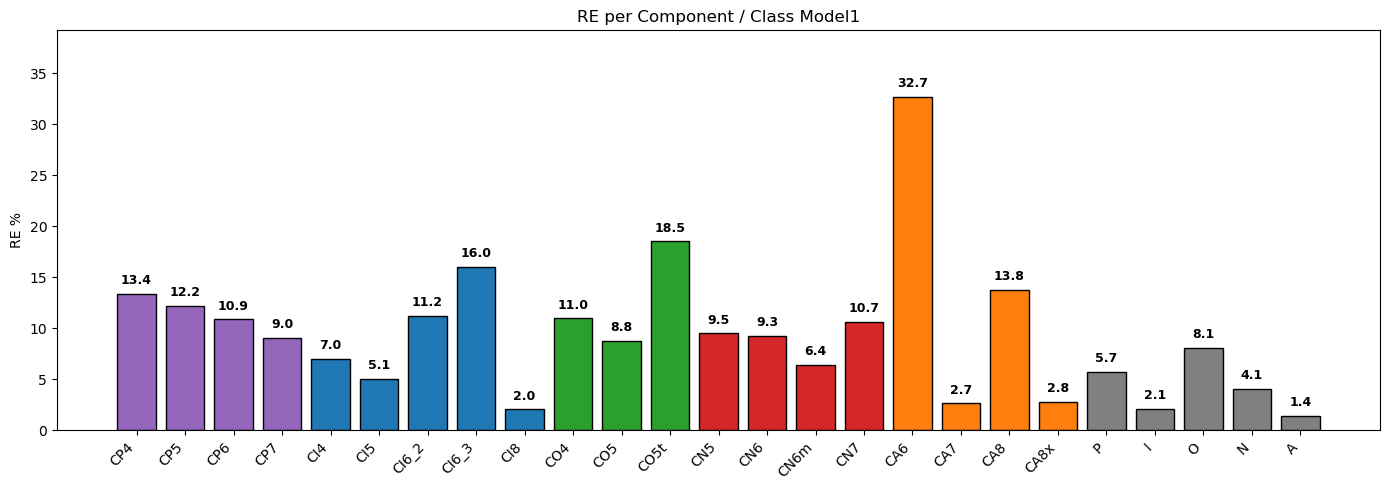

In [49]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O",'N',"A"]

colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, RE, color=colors, edgecolor='black')


y_off = 0.02 * np.max(RE)

for bar, val in zip(bars, RE):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.1f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("RE %")
ax.set_title("RE per Component / Class Model1")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(RE) * 1.2)

plt.tight_layout()
plt.show()

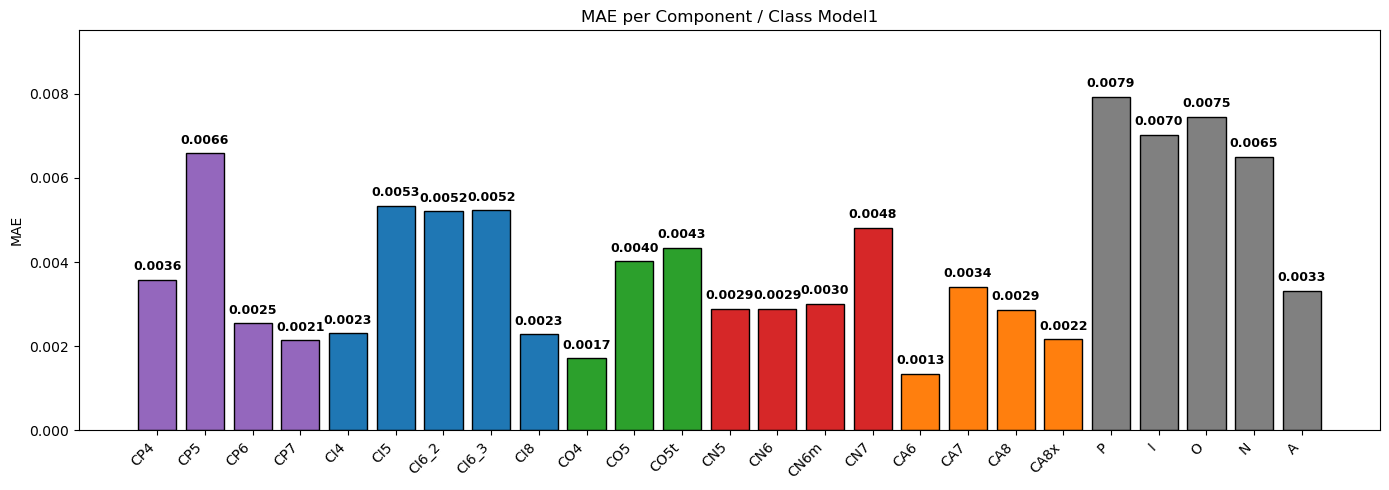

In [50]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O","N","A"]


colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, MAE, color=colors, edgecolor='black')


y_off = 0.02 * np.max(MAE)

for bar, val in zip(bars, MAE):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.4f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("MAE")
ax.set_title("MAE per Component / Class Model1")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(MAE) * 1.2)

plt.tight_layout()
plt.show()

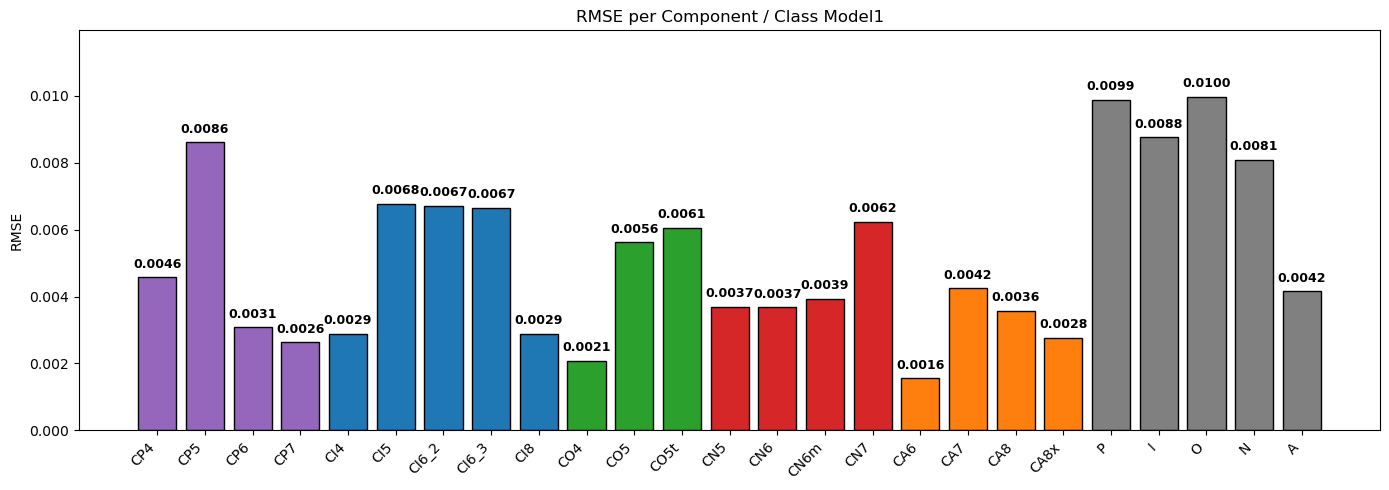

In [51]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O","N","A"]

colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, RMSE, color=colors, edgecolor='black')


y_off = 0.02 * np.max(RMSE)

for bar, val in zip(bars, RMSE):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.4f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("RMSE")
ax.set_title("RMSE per Component / Class Model1")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(RMSE) * 1.2)

plt.tight_layout()
plt.show()

In [52]:
print(y_pred[1000][-9])

0.004238275


In [53]:
print(y_test[1000][-9])

0.003


Second Structure

In [37]:
class Sum_Layer(keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=-1, keepdims=True)

In [35]:
inp1 = keras.layers.Input(shape=x_train.shape[1:])
x1 = keras.layers.Dense(20,kernel_initializer = 'lecun_normal')(inp1)
x1 = keras.layers.Activation('selu')(x1)


x1 = keras.layers.Dense(20, kernel_initializer = 'lecun_normal')(x1)
x1 = keras.layers.Activation('selu')(x1)
x1 = keras.layers.Dense(20, kernel_initializer = 'lecun_normal')(x1)
x1 = keras.layers.Activation('selu')(x1)
x1 = keras.layers.Dense(20, kernel_initializer = 'lecun_normal')(x1)
x1 = keras.layers.Activation('selu')(x1)
out1 = keras.layers.Dense(20, activation='softmax', name = 'subsets')(x1)

x1p = keras.layers.Lambda(lambda t: t[:, 0:4])(out1)
x2i = keras.layers.Lambda(lambda t: t[:, 4:9])(out1)
x3o = keras.layers.Lambda(lambda t: t[:, 9:12])(out1)
x4n = keras.layers.Lambda(lambda t: t[:, 12:16])(out1)
x5a = keras.layers.Lambda(lambda t: t[:, 16:20])(out1)


P = Sum_Layer(name="P")(x1p) 
I = Sum_Layer(name="I")(x2i) 
O = Sum_Layer(name="O")(x3o) 
N = Sum_Layer(name="N")(x4n) 
A = Sum_Layer(name="A")(x5a)


out2 = keras.layers.concatenate([out1, P, I, O, N,A])
model2 = keras.Model(inputs = inp1, outputs =out2)

In [40]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20)        │        280 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 20)        │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20)        │        420 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 20)        │          0 │ dense_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20)        │        420 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 20)        │          0 │ dense_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20)        │        420 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 20)        │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subsets (Dense)     │ (None, 20)        │        420 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 4)         │          0 │ subsets[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 5)         │          0 │ subsets[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 3)         │          0 │ subsets[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 4)         │          0 │ subsets[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ subsets[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ P (Sum_Layer)       │ (None, 1)         │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ I (Sum_Layer)       │ (None, 1)         │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ O (Sum_Layer)       │ (None, 1)         │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ N (Sum_Layer)       │ (None, 1)         │          0 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ A (Sum_Layer)       │ (None, 1)         │          0 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 25)        │          0 │ subsets[0][0],    │
│ (Concatenate)       │                   │            │ P[0][0], I[0][0], │
│                     │                   │            │ O[0][0], N[0][0], │
│                     │                   │            │ A[0][0]         

 Total params: 1,960 (7.66 KB)

 Trainable params: 1,960 (7.66 KB)

 Non-trainable params: 0 (0.00 B)

Callbacks, Optimizer, Losses and fit of the model

In [41]:
er_stop2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [47]:
model2.compile(
        optimizer=keras.optimizers.AdamW(learning_rate = lr_schedule),
        loss='huber',
        metrics=["mse", 'mae']
    )

In [200]:
history2 = model2.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=600, batch_size = 32, callbacks=[er_stop2], shuffle=True)

Epoch 1/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.5541e-04 - mae: 0.0110 - mse: 3.1081e-04 - val_loss: 4.1033e-05 - val_mae: 0.0066 - val_mse: 8.2067e-05
Epoch 2/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.6925e-05 - mae: 0.0062 - mse: 7.3850e-05 - val_loss: 3.1164e-05 - val_mae: 0.0056 - val_mse: 6.2328e-05
Epoch 3/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.8204e-05 - mae: 0.0054 - mse: 5.6408e-05 - val_loss: 2.4923e-05 - val_mae: 0.0051 - val_mse: 4.9846e-05
Epoch 4/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.3853e-05 - mae: 0.0050 - mse: 4.7706e-05 - val_loss: 2.3855e-05 - val_mae: 0.0050 - val_mse: 4.7710e-05
Epoch 5/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.3342e-05 - mae: 0.0050 - mse: 4.6683e-05 - val_loss: 2.1962e-05 - val_mae: 0.0048 - val_mse: 4.3924e-05
Epoch 6/600
2047/2047 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.1136e-05 - mae: 0.0047 - mse: 4.2272e-05 - val_loss: 1.9932e-05 - val_mae: 0.0046 - val_ms

Saving model weights and history object

In [99]:
hist_df = pd.DataFrame(history2.history)
hist_df.to_csv("training_history_selu_softmax.csv", index=False)

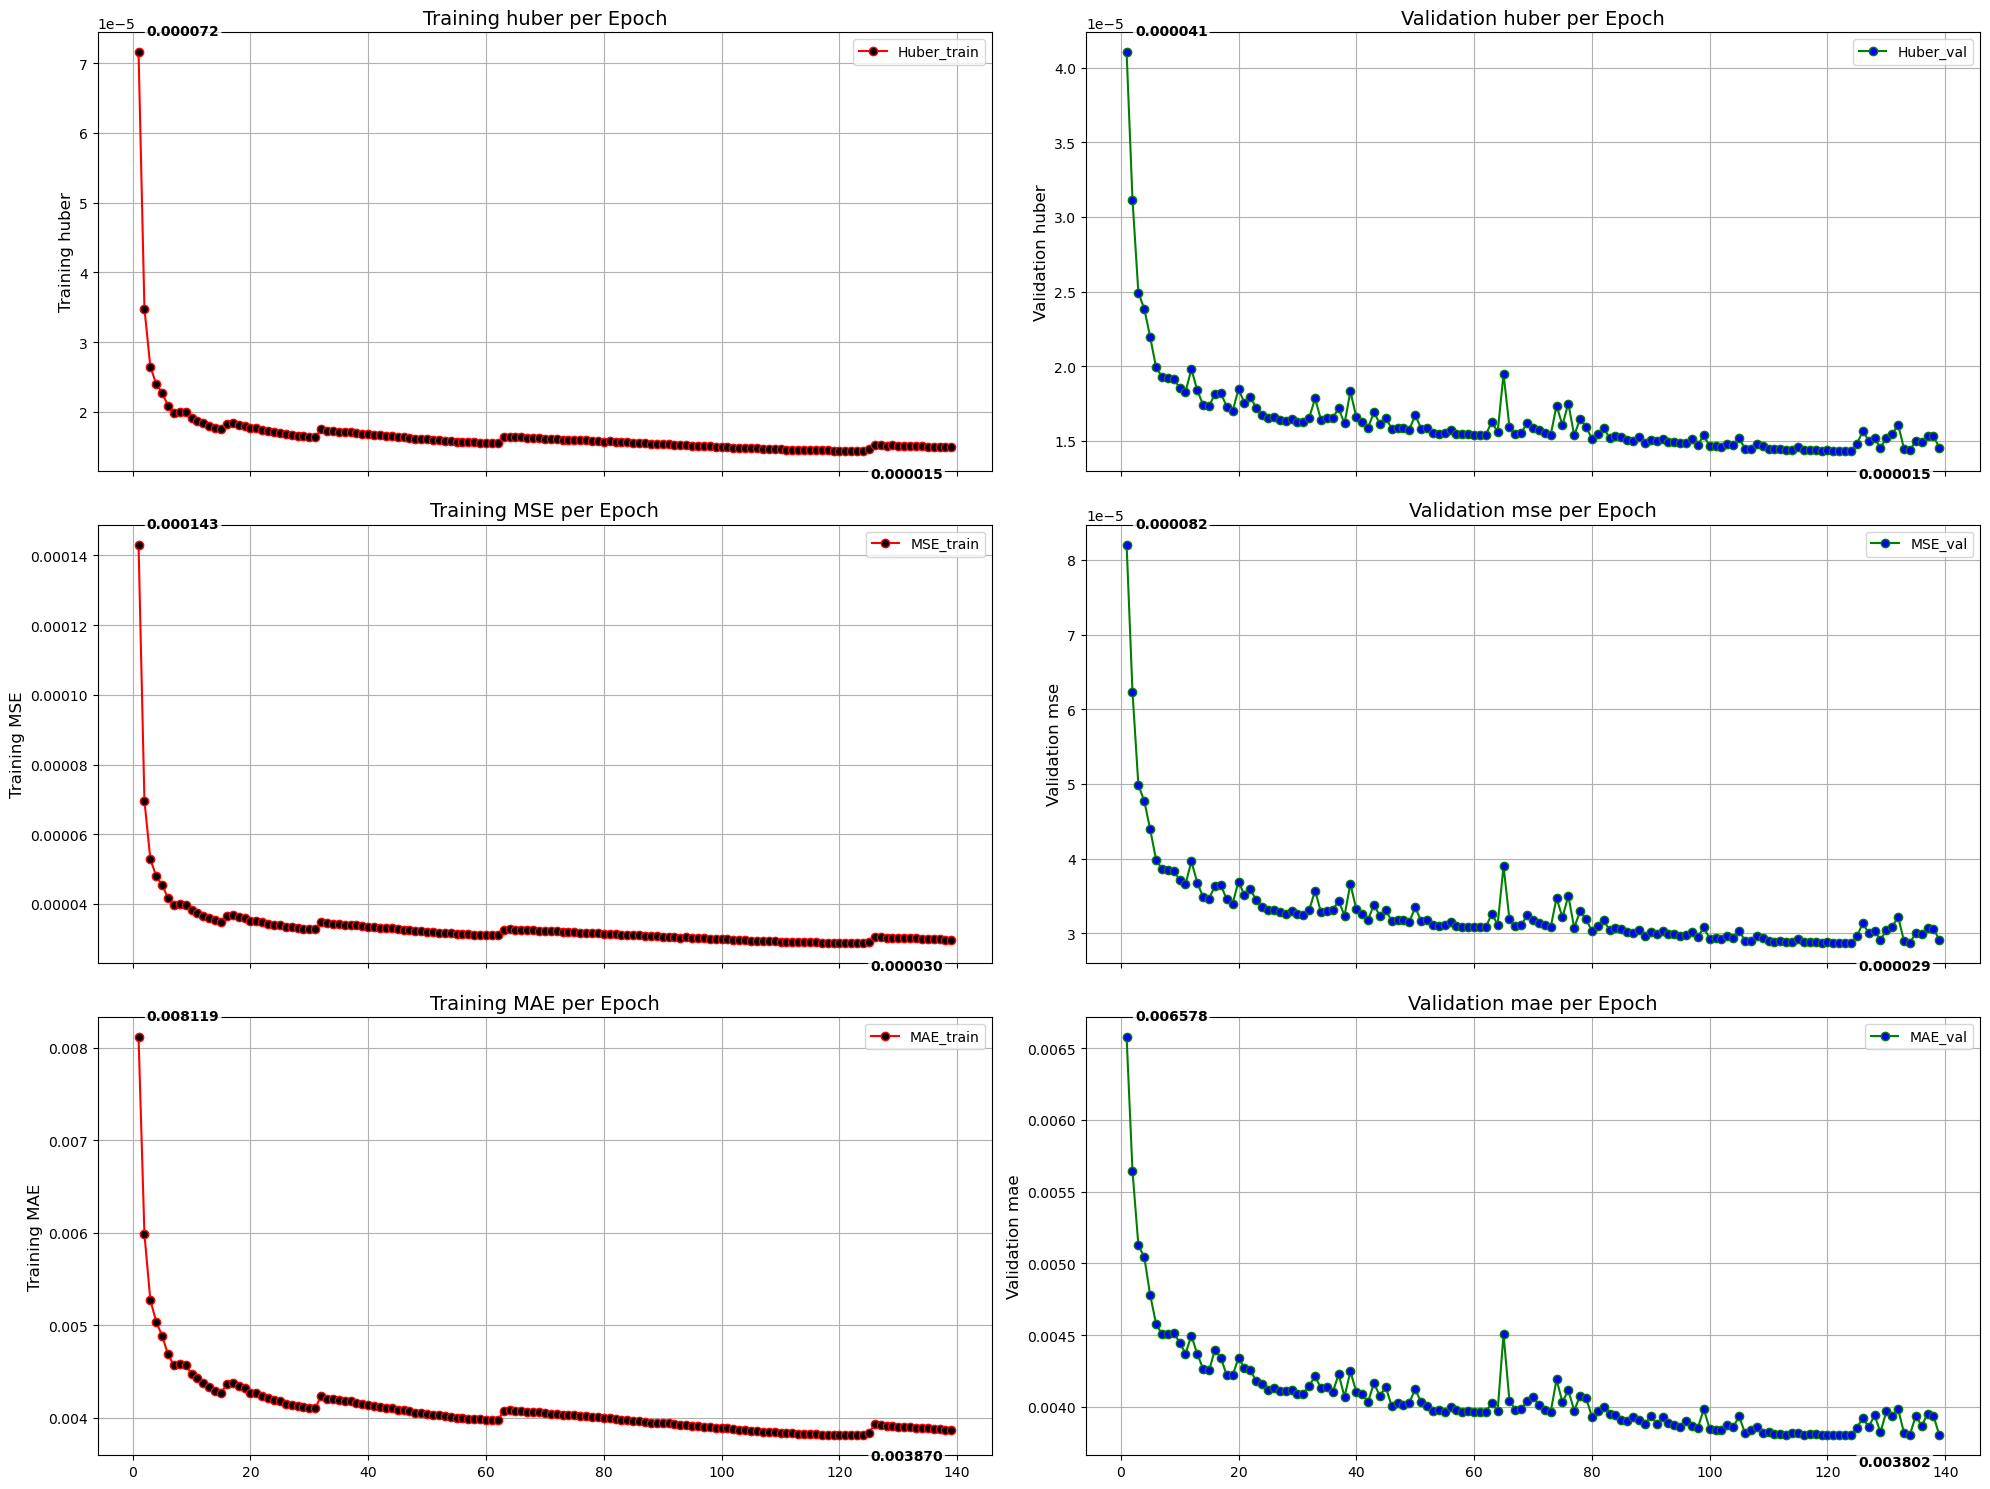

In [205]:
train_huber = history2.history['loss']
val_huber = history2.history['val_loss']
train_mse = history2.history['mse']
val_mse = history2.history['val_mse']
train_mae = history2.history['mae']
val_mae = history2.history['val_mae']

epochs = range(1, len(train_huber) + 1)

fig, axs = plt.subplots(3, 2, figsize=(20, 15), sharex=True)


axs[0,0].plot(epochs, train_huber, label='Huber_train', marker='o', markerfacecolor='black', color='red')
ends(axs[0,0], epochs, train_huber, fmt="{:.6f}")
axs[0,0].set_ylabel('Training huber', fontsize=12)
axs[0,0].set_title('Training huber per Epoch', fontsize=14)
axs[0,0].grid(True)
axs[0,0].legend()

axs[0,1].plot(epochs, val_huber, label='Huber_val', marker='o', markerfacecolor='blue', color='green')
ends(axs[0,1], epochs, val_huber, fmt="{:.6f}")
axs[0,1].set_ylabel('Validation huber', fontsize=12)
axs[0,1].set_title('Validation huber per Epoch', fontsize=14)
axs[0,1].grid(True)
axs[0,1].legend()

axs[1,0].plot(epochs, train_mse, label='MSE_train', marker='o', markerfacecolor='black', color='red')
ends(axs[1,0], epochs, train_mse, fmt="{:.6f}")
axs[1,0].set_ylabel('Training MSE', fontsize=12)
axs[1,0].set_title('Training MSE per Epoch', fontsize=14)
axs[1,0].grid(True)
axs[1,0].legend()

axs[1,1].plot(epochs, val_mse, label='MSE_val', marker='o', markerfacecolor='blue', color='green')
ends(axs[1,1], epochs, val_mse, fmt="{:.6f}")
axs[1,1].set_ylabel('Validation mse', fontsize=12)
axs[1,1].set_title('Validation mse per Epoch', fontsize=14)
axs[1,1].grid(True)
axs[1,1].legend()

axs[2,0].plot(epochs, train_mae, label='MAE_train', marker='o', markerfacecolor='black', color='red')
ends(axs[2,0], epochs, train_mae, fmt="{:.6f}")
axs[2,0].set_ylabel('Training MAE', fontsize=12)
axs[2,0].set_title('Training MAE per Epoch', fontsize=14)
axs[2,0].grid(True)
axs[2,0].legend()

axs[2,1].plot(epochs, val_mae, label='MAE_val', marker='o', markerfacecolor='blue', color='green')
ends(axs[2,1], epochs, val_mae, fmt="{:.6f}")
axs[2,1].set_ylabel('Validation mae', fontsize=12)
axs[2,1].set_title('Validation mae per Epoch', fontsize=14)
axs[2,1].grid(True)
axs[2,1].legend()

plt.tight_layout()
plt.show()

Checking output constraint on second model

In [50]:
y_val_pred = evaluate_25(model2, x_val, y_val, name="VAL")


=== VAL ===
MAE (20 comps)                 : 0.003370
RMSE (20 comps)                : 0.004693
MAE (PIONA 5)                  : 0.005646
RMSE (PIONA 5)                 : 0.007585
Neg rate (20)                  : 0.00%
Neg rate (5)                   : 0.00%
Sum(20) mean / |err|           : 1.000000 / 0.000000
Sum(5)  mean / |err|           : 1.000000 / 0.000000
Group-sum vs parent (pred) MAE : 0.000000
Group-sum vs parent (true)  MAE: 0.005646


In [51]:
y_test_pred = evaluate_25(model2, x_test, y_test, name="test")


=== test ===
MAE (20 comps)                 : 0.003356
RMSE (20 comps)                : 0.004667
MAE (PIONA 5)                  : 0.005585
RMSE (PIONA 5)                 : 0.007477
Neg rate (20)                  : 0.00%
Neg rate (5)                   : 0.00%
Sum(20) mean / |err|           : 1.000000 / 0.000000
Sum(5)  mean / |err|           : 1.000000 / 0.000000
Group-sum vs parent (pred) MAE : 0.000000
Group-sum vs parent (true)  MAE: 0.005585


Checking test datas on the second model

In [38]:
model2 = keras.models.load_model('selus.keras', custom_objects={"Sum_Layer": Sum_Layer},safe_mode=False)

In [39]:
model2.evaluate(x_test, y_test, return_dict=True)

439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.4274e-05 - mae: 0.0038 - mse: 2.8547e-05


{'loss': 1.4304086107586045e-05,
 'mae': 0.003801762592047453,
 'mse': 2.860817221517209e-05}

In [45]:
y_pred2 = model2.predict(x_test)

mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.4f}")

439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
RMSE: 0.0053


In [210]:
y_pred2[2000][-9]

0.004280136

In [211]:
y_test[2000][-9]

0.003

In [46]:
SMAPE2 = smape_per_col(y_test, y_pred2)
MSE2 = mse_per_col(y_test, y_pred2)
MAE2 = mae_per_col(y_test, y_pred2)
RMSE2 = rmse_per_col(y_test, y_pred2)
RE2 = relative_error_per_col(y_test, y_pred2)
SMAPE2

array([ 6.2655606 ,  5.79987   ,  5.455057  ,  4.5412803 ,  3.1657438 ,
        2.434392  ,  5.4790397 ,  7.582385  ,  1.0099019 ,  5.2284403 ,
        3.813088  ,  7.343339  ,  4.5344596 ,  4.3983912 ,  3.1928937 ,
        4.9748464 , 15.118152  ,  1.1686751 ,  6.653223  ,  1.5055666 ,
        2.3992517 ,  0.93757296,  3.4508505 ,  1.7251465 ,  0.62714434],
      dtype=float32)

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
mpl.rcParams["animation.ffmpeg_path"] = r"C:\Users\Rayanegostar\anaconda3\Library\bin\ffmpeg.exe"
# ------------------------------------------------------------------
# 1) Your data
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O",'N',"A"]



# Colors EXACTLY like your code
colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

# Optional: if ffmpeg isn't on PATH, set it explicitly:
# import matplotlib as mpl
# mpl.rcParams["animation.ffmpeg_path"] = r"C:\Users\...\ffmpeg.exe"
# ------------------------------------------------------------------

# 2) Figure & initial bars (height=0)
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, np.zeros_like(SMAPE2), color=colors, edgecolor='black')

ax.set_ylabel("SMAPE %")
ax.set_title("SMAPE per Component / Class Model2")
plt.xticks(rotation=45, ha='right')

ymax = float(SMAPE2.max()) * 1.2
ax.set_ylim(0, ymax)
y_off = 0.02 * SMAPE2.max()  # label offset

# Create text labels once; we’ll update their positions/text in the animation
labels = []
for bar in bars:
    txt = ax.text(
        bar.get_x() + bar.get_width() / 2,
        0.0,
        "", ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
    labels.append(txt)

# 3) Animation
frames = 160          # more frames = smoother, fewer = faster
fps     = 40          # output video speed
# Use a smooth easing for a nice ramp (0..1 -> 0..1)
def ease(t):  # cubic ease-out
    return 1 - (1 - t) ** 3

def init():
    for bar in bars:
        bar.set_height(0.0)
    for txt in labels:
        txt.set_text("")
        txt.set_y(0.0)
    return (*bars, *labels)

def update(f):
    t = ease(f / (frames - 1))
    heights = SMAPE2 * t
    for bar, h, val, txt in zip(bars, heights, SMAPE2, labels):
        bar.set_height(h)
        txt.set_text(f"{(val*t):.1f}")  # current animated value
        txt.set_y(h + y_off)
    return (*bars, *labels)

anim = FuncAnimation(
    fig, update, init_func=init, frames=frames,
    interval=1000/fps, blit=True
)

# 4) Save MP4
writer = FFMpegWriter(fps=fps, bitrate=3000)
anim.save("SMAPE_bars.mp4", writer=writer)
plt.close(fig)
print("Saved: SMAPE_bars.mp4")

Saved: SMAPE_bars.mp4


In [43]:
MSE2

array([2.28363169e-05, 7.22101322e-05, 9.50230606e-06, 6.69608198e-06,
       7.58626084e-06, 4.32426750e-05, 4.55154841e-05, 4.30755790e-05,
       8.06144362e-06, 4.33202649e-06, 2.78491825e-05, 3.33880744e-05,
       1.35700666e-05, 1.28782158e-05, 1.59367337e-05, 3.59334408e-05,
       2.43559816e-06, 1.49601401e-05, 1.26444938e-05, 7.87363388e-06,
       7.47521553e-05, 6.36593977e-05, 8.43597008e-05, 5.03830670e-05,
       1.45117765e-05], dtype=float32)

In [214]:
MAE2

array([0.00373357, 0.00644572, 0.0025563 , 0.00210293, 0.00215148,
       0.00512531, 0.00517325, 0.00513625, 0.00224702, 0.00167916,
       0.00375474, 0.00407285, 0.00286248, 0.0027905 , 0.00302335,
       0.00459882, 0.0013214 , 0.00300898, 0.00288097, 0.00228215,
       0.00660493, 0.00629878, 0.00660918, 0.00550648, 0.00300725],
      dtype=float32)

In [215]:
RMSE2

array([0.00473777, 0.00840213, 0.0030841 , 0.0025761 , 0.00271463,
       0.00657387, 0.00663183, 0.00652249, 0.00282733, 0.00205395,
       0.00522039, 0.00566416, 0.00365808, 0.00358616, 0.00394059,
       0.00597692, 0.00155219, 0.00386072, 0.00356936, 0.00284425,
       0.00856817, 0.00795991, 0.00898164, 0.00704528, 0.00382972],
      dtype=float32)

In [216]:
RE2

array([13.727626 , 12.05773  , 11.13982  ,  9.077872 ,  6.3634596,
        4.8825583, 11.072089 , 15.799915 ,  2.0069857, 10.703613 ,
        8.004254 , 16.75155  ,  9.398196 ,  9.087175 ,  6.5542417,
       10.20806  , 31.683153 ,  2.3555977, 13.920299 ,  2.999303 ,
        4.8842793,  1.8670132,  7.1184464,  3.471334 ,  1.2718182],
      dtype=float32)

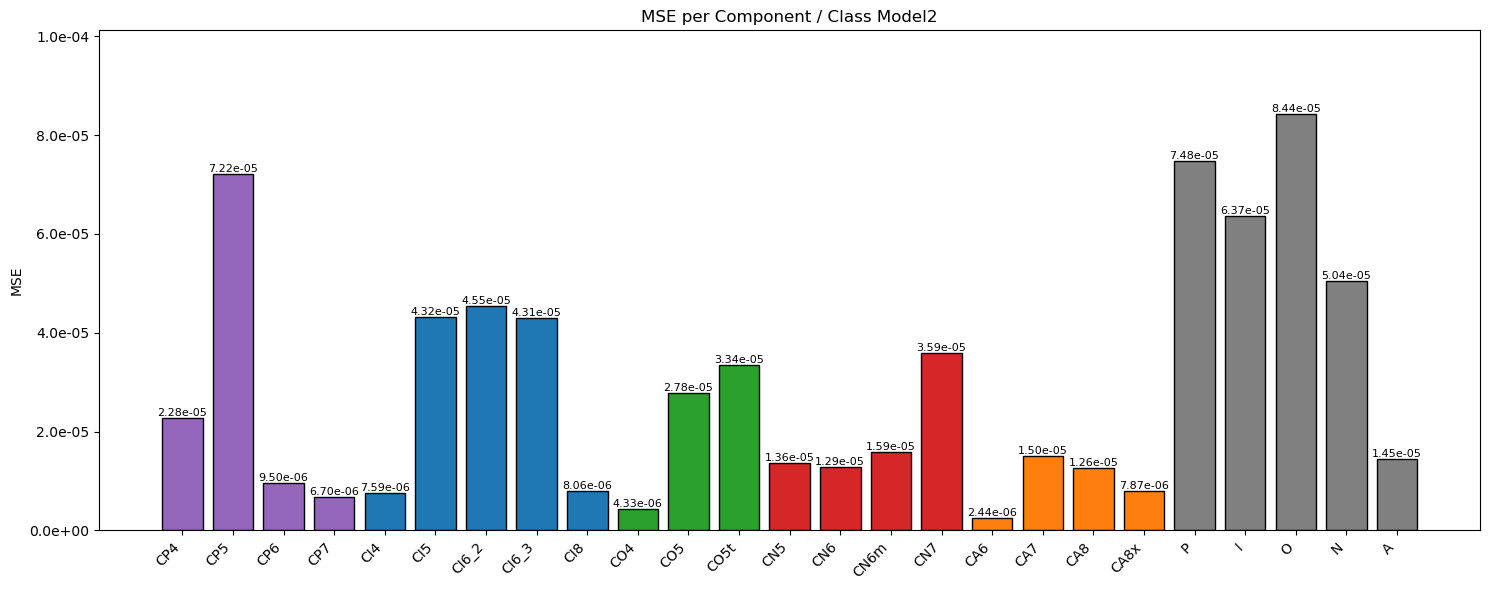

In [44]:
import matplotlib.ticker as ticker

names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O",'N',"A"]
colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(15,6))
bars = ax.bar(names, MSE2, color=colors, edgecolor='black')


y_off = 0.02 * np.max(MSE2)

for p, v in zip(bars, MSE2):
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f"{v:.2e}", ha='center', va='bottom', fontsize=8)
    
ax.set_ylabel("MSE")
ax.set_title("MSE per Component / Class Model2")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(MSE2) * 1.2)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
plt.tight_layout()
plt.show()


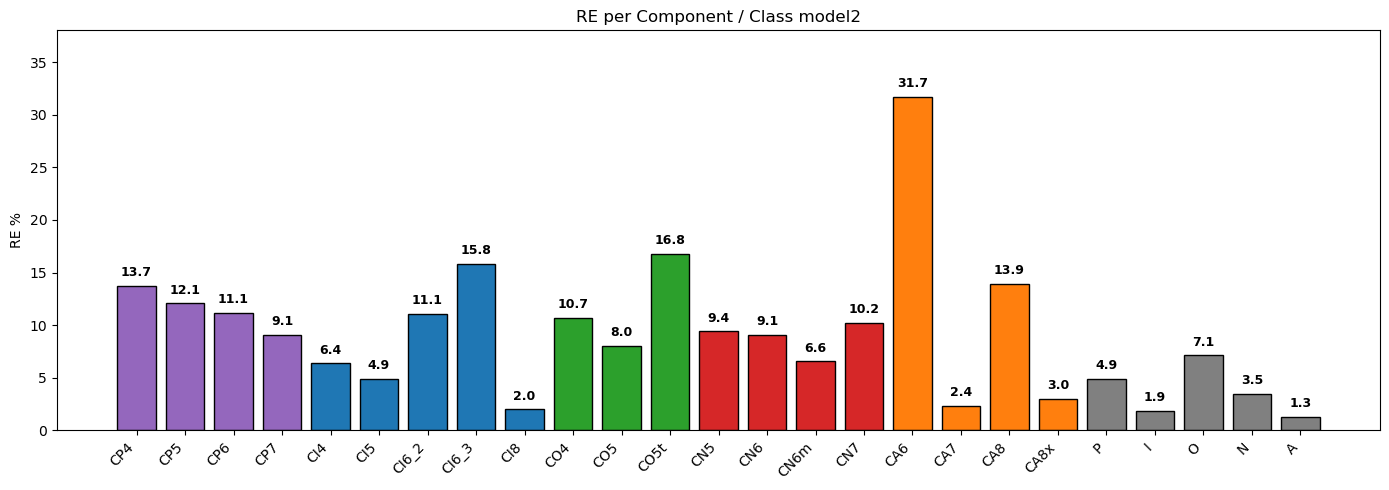

In [218]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O",'N',"A"]

colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, RE2, color=colors, edgecolor='black')


y_off = 0.02 * np.max(RE2)

for bar, val in zip(bars, RE2):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.1f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("RE %")
ax.set_title("RE per Component / Class model2")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(RE2) * 1.2)

plt.tight_layout()
plt.show()

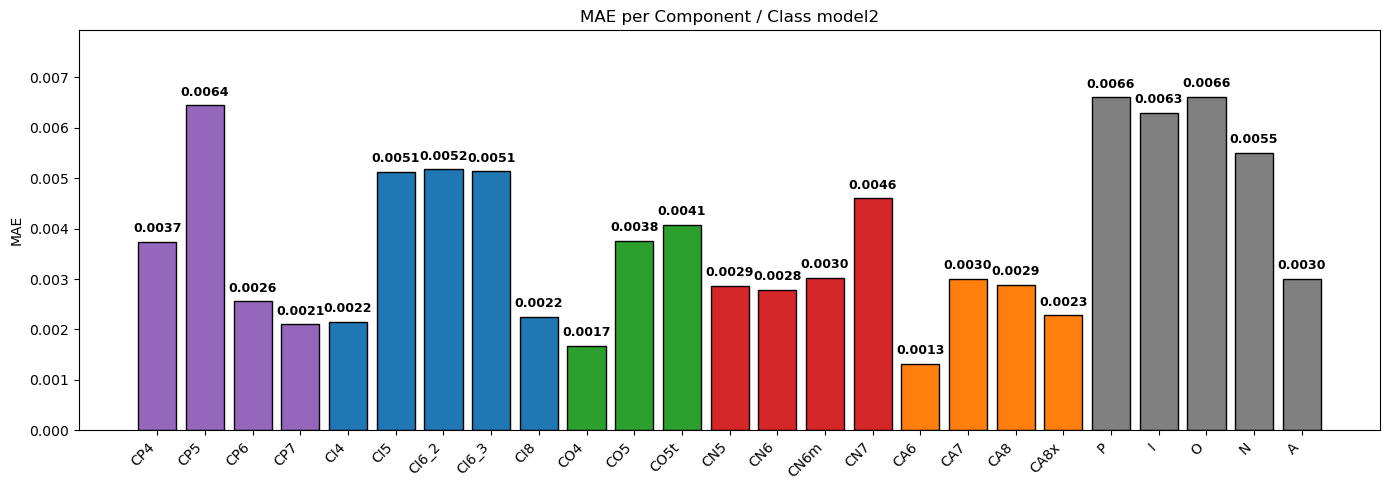

In [220]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O","N","A"]


colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, MAE2, color=colors, edgecolor='black')


y_off = 0.02 * np.max(MAE2)

for bar, val in zip(bars, MAE2):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.4f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("MAE")
ax.set_title("MAE per Component / Class model2")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(MAE2) * 1.2)

plt.tight_layout()
plt.show()

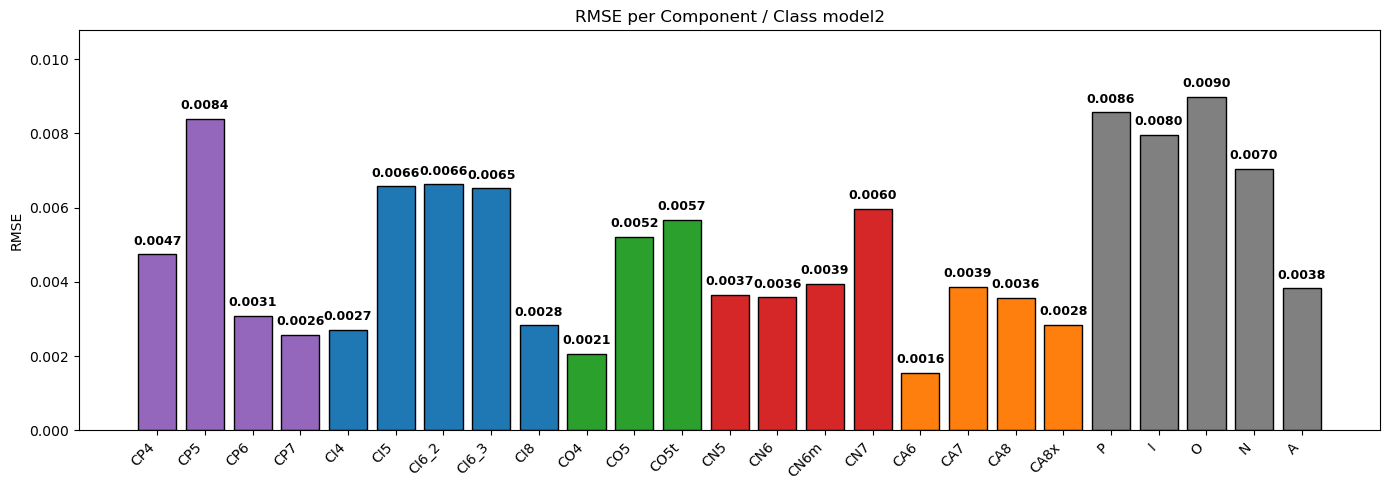

In [221]:
names = ["CP4","CP5","CP6","CP7","CI4","CI5","CI6_2","CI6_3","CI8",
         "CO4","CO5","CO5t","CN5","CN6","CN6m","CN7","CA6","CA7","CA8","CA8x",
         "P","I","O","N","A"]

colors = []
for n in names:
    if n.startswith("CP"): colors.append("tab:purple")
    elif n.startswith("CI"): colors.append("tab:blue")
    elif n.startswith("CO"): colors.append("tab:green")
    elif n.startswith("CN"): colors.append("tab:red")
    elif n.startswith("CA"): colors.append("tab:orange")
    else: colors.append("gray")

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(names, RMSE2, color=colors, edgecolor='black')


y_off = 0.02 * np.max(RMSE2)

for bar, val in zip(bars, RMSE2):
    ax.text(bar.get_x() + bar.get_width()/2, 
            val + y_off, 
            f"{val:.4f}",   
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("RMSE")
ax.set_title("RMSE per Component / Class model2")
plt.xticks(rotation=45, ha='right')


ax.set_ylim(0, np.max(RMSE2) * 1.2)

plt.tight_layout()
plt.show()

Writing a checker function to identify good and bad gasolines

Testing good gasoline

In [21]:
y_pred = model2.predict(x_test)

439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [244]:
Names = ["CP4","CP5","CP6","CP7",
             "CI4","CI5","CI6_2","CI6_3","CI8",
             "CO4","CO5","CO5t",
             "CN5","CN6","CN6m","CN7",
             "CA6","CA7","CA8","CA8x",
             "P","I","O","N","A"]

Comps = Names[:20]   
Piona       = Names[-5:]   

COMP_BOUNDS = {
    "CP4": (0.010, 0.050),
    "CP5": (0.030, 0.080),
    "CP6": (0.015, 0.030),
    "CP7": (0.015, 0.030),
    "CI4": (0.020, 0.050),
    "CI5": (0.090, 0.120),
    "CI6_2": (0.030, 0.070),
    "CI6_3": (0.020, 0.050),
    "CI8": (0.090, 0.140),
    "CO4": (0.010, 0.020),
    "CO5": (0.030, 0.060),
    "CO5t": (0.010, 0.040),
    "CN5": (0.020, 0.040),
    "CN6": (0.020, 0.040),
    "CN6m": (0.030, 0.060),
    "CN7": (0.030, 0.060),
    "CA6": (0.003, 0.008),
    "CA7": (0.090, 0.180),
    "CA8": (0.010, 0.030),
    "CA8x": (0.050, 0.100),
}

PIONA_BOUNDS = {
    "P": (0.070, 0.190),
    "I": (0.250, 0.430),
    "O": (0.050, 0.120),
    "N": (0.100, 0.200),
    "A": (0.153, 0.318),
}

In [430]:
def bounds(lows, highs, tol_abs):
    lows_tol  = np.clip(lows  - tol_abs, 0.0, 1.0)
    highs_tol = np.clip(highs + tol_abs, 0.0, 1.0)
    return lows_tol, highs_tol

def Quality_check(y_pred,
                        comp_bounds=COMP_BOUNDS,piona_bounds=PIONA_BOUNDS,tol_abs=0.01):
    #Comps
    Gc = y_pred[:, :20]
    comp_names = list(comp_bounds.keys())

    lows_c  = np.array([comp_bounds[c][0] for c in comp_names], dtype=float)
    highs_c = np.array([comp_bounds[c][1] for c in comp_names], dtype=float)
    lows_c_tol, highs_c_tol = bounds(lows_c, highs_c, tol_abs)

    mask_c = (Gc >= lows_c_tol) & (Gc <= highs_c_tol)
    status_c = np.where(mask_c, "GOOD", "BAD")
    overall_components = np.where(mask_c.all(axis=1), "GOOD", "BAD")

    df_vals_c = pd.DataFrame(Gc, columns=comp_names)
    df_stat_c = pd.DataFrame(status_c, columns=[f"{c}_status" for c in comp_names])

    #PIONA
    Gp = y_pred[:, -5:]
    piona_names = list(piona_bounds.keys())  
    lows_p  = np.array([piona_bounds[g][0] for g in piona_names], dtype=float)
    highs_p = np.array([piona_bounds[g][1] for g in piona_names], dtype=float)
    lows_p_tol, highs_p_tol = bounds(lows_p, highs_p, tol_abs)

    mask_p = (Gp >= lows_p_tol) & (Gp <= highs_p_tol)
    status_p = np.where(mask_p, "GOOD", "BAD")
    overall_piona = np.where(mask_p.all(axis=1), "GOOD", "BAD")

    df_vals_p = pd.DataFrame(Gp, columns=piona_names)
    df_stat_p = pd.DataFrame(status_p, columns=[f"{g}_status" for g in piona_names])

    out = pd.concat([df_vals_c, df_stat_c, df_vals_p, df_stat_p], axis=1)
    out["Overall_Components"] = overall_components
    out["Overall_PIONA"] = overall_piona
    out["Overall_Final"] = np.where(
        (overall_components == "GOOD") & (overall_piona == "GOOD"),
        "GOOD", "BAD"
    )
    return out

Testing random gasolines

Loading, Extracting and normalizing good and random datasets of gasoline

In [431]:
x_bad_df = pd.read_csv(r"C:\Neural\Project\Hysys sim\Inputs_Rand.csv")
y_bad_df = pd.read_csv(r"C:\Neural\Project\Hysys sim\Outputs_Rand.csv")
x_good_df = pd.read_csv(r"C:\Neural\Project\Hysys sim\Inputs_Fine.csv")
y_good_df = pd.read_csv(r"C:\Neural\Project\Hysys sim\Outputs_Fine.csv")

In [432]:
InputsGood_normalized = (x_good_df-col_min)/(col_max-col_min)
InputsBad_normalized = (x_bad_df - col_min) / (col_max - col_min)

In [470]:
Min_Max_df = pd.concat([col_min, col_max], axis=1)
Min_Max_df.columns = ['Min', 'Max']
Min_Max_df.to_csv("MinMax_train.csv", index=False)

In [433]:
x_bad = InputsBad_normalized.values.astype("float32")
y_bad = y_bad_df.values.astype("float32")

In [434]:
x_good = InputsGood_normalized.values.astype("float32")
y_good = y_good_df.values.astype("float32")

Evaluating model metrics on good and bad gasoline datasets

In [435]:
model2.evaluate(x_bad, y_bad)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045 - mae: 0.0556 - mse: 0.0091


[0.004374756012111902, 0.008749512024223804, 0.05524620786309242]

In [436]:
model2.evaluate(x_good, y_good)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4712e-05 - mae: 0.0038 - mse: 2.9424e-05


[1.4620473848481197e-05, 2.9240947696962394e-05, 0.003825975814834237]

Predicting outputs with model2

In [437]:
y_pred_good = model2.predict(x_good)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step


In [438]:
y_pred_bad = model2.predict(x_bad)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step


Checking the quality of the gasoline for good and bad gasolines

In [455]:
quality_bad = Quality_check(y_pred_bad,
                        comp_bounds=COMP_BOUNDS,
                        piona_bounds=PIONA_BOUNDS,
                        tol_abs=0.004)
quality_bad.to_csv('quality_bad.csv', index = False)

In [456]:
print(quality_bad["Overall_Final"].value_counts())

Overall_Final
BAD    5000
Name: count, dtype: int64


In [462]:
quality_good = Quality_check(y_pred_good,
                        comp_bounds=COMP_BOUNDS,
                        piona_bounds=PIONA_BOUNDS,
                        tol_abs=0.005)
quality_good.to_csv('quality_good.csv', index = False)

In [463]:
print(quality_good["Overall_PIONA"].value_counts())

Overall_PIONA
GOOD    5000
Name: count, dtype: int64


In [449]:
y_pred_good[77][6]

0.07509567

In [450]:
y_good[77][6]

0.064510174